In [1]:
# 🔧 ADAPTATION LOCALE : Pas besoin Google Drive sur Linux
import os
import sys
from pathlib import Path

# Définir les chemins de base
PROJECT_ROOT = Path.home() / "Documents/IFT714 Traitement des LN/Projet/Detection_fake_news"
KNOWLEDGE_BRANCH = PROJECT_ROOT / "knowledge_branch"
DATA_DIR = PROJECT_ROOT / "data" / "knowledge_based"

print(f"📂 Répertoire de travail : {KNOWLEDGE_BRANCH}")
print(f"✅ Projet trouvé : {PROJECT_ROOT.exists()}")
print(f"✅ Data trouvée : {DATA_DIR.exists()}")

# Ajouter le knowledge_branch aux imports Python
sys.path.insert(0, str(KNOWLEDGE_BRANCH))

📂 Répertoire de travail : /home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/knowledge_branch
✅ Projet trouvé : True
✅ Data trouvée : True


In [2]:
# HuggingFace login (optionnel - uniquement si vous avez un compte)
# Décommentez si vous avez besoin de télécharger des modèles privés
try:
    from huggingface_hub import login
    # login()  # À décommenter et configurer si nécessaire
    print("✅ HuggingFace Hub disponible")
except ImportError:
    print("⚠️ huggingface_hub non disponible - utilisation des modèles publics uniquement")

✅ HuggingFace Hub disponible


In [3]:
import os
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'🎮 Device : {device.upper()} - {device_name}')
print(f'💾 GPU VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else '')

🎮 Device : CUDA - NVIDIA GeForce RTX 4060
💾 GPU VRAM disponible : 8.2 GB


In [4]:
# Afficher les répertoires du projet
print(f"\n📂 Contenu du répertoire de travail:")
for item in sorted(KNOWLEDGE_BRANCH.iterdir()):
    print(f"  {'📁' if item.is_dir() else '📄'} {item.name}")


📂 Contenu du répertoire de travail:
  📁 __pycache__
  📄 claim_detection.py
  📁 claim_detector_model
  📄 claim_verification.py
  📄 evidence_retrieval.py
  📄 groundtruth.csv
  📄 knowledge.ipynb
  📄 knowledge_based_tests.ipynb
  📁 results
  📄 train.jsonl


In [5]:
# Changement de répertoire local (déjà configuré via PROJECT_ROOT)
print(f"✅ Répertoire courant : {KNOWLEDGE_BRANCH}")

✅ Répertoire courant : /home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/knowledge_branch


In [6]:
# Liste les fichiers dans le répertoire de travail
print("\n📂 Fichiers principaux :")
for item in sorted(KNOWLEDGE_BRANCH.glob('*.py')):
    print(f"  📄 {item.name}")


📂 Fichiers principaux :
  📄 claim_detection.py
  📄 claim_verification.py
  📄 evidence_retrieval.py


# Claim detection

In [7]:
!pip install transformers torch spacy pandas
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [8]:
# Téléchargement du fichier "groundtruth" (le plus fiable pour le fine-tuning)
!wget https://zenodo.org/api/records/3609356/files/groundtruth.csv/content -O groundtruth.csv



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://zenodo.org/api/records]87Saving 'groundtruth.csv'
87groundtruth.csv        0% [<=>                           ]   48.88K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87groundtruth.csv      100% [=============================>]   52.64K  627.76KB/s87HTTP response 200 OK [https://zenodo.org/api/records/3609356/files/groundtruth.csv/content]
87groundtruth.csv      100% [=============================>]   52.64K  627.76KB/s87[Files: 1  Bytes: 52.64K [52.33]8

In [9]:
import pandas as pd

dataset = pd.read_csv("groundtruth.csv")
print(dataset.head())
print(dataset.columns.to_list)
print(dataset['Verdict'].value_counts())
print(dataset.shape)

# On crée une colonne 'labels' binaire : 1 pour le niveau 1, 0 pour le reste
dataset['labels'] = dataset['Verdict'].apply(lambda x: 1 if x == 1 else 0)



# On ne garde que le texte et le nouveau label
dataset = dataset[['Text', 'labels']]



   Sentence_id                                               Text  \
0           26      You know, I saw a movie - "Crocodile Dundee."   
1           80  We're consuming 50 percent of the world's coca...   
2          129   That answer was about as clear as Boston harbor.   
3          131                          Let me help the governor.   
4          172  We've run up more debt in the last eight years...   

           Speaker   Speaker_title Speaker_party         File_id  Length  \
0      George Bush  Vice President    REPUBLICAN  1988-09-25.txt       9   
1  Michael Dukakis        Governor      DEMOCRAT  1988-09-25.txt       8   
2      George Bush  Vice President    REPUBLICAN  1988-09-25.txt       9   
3      George Bush  Vice President    REPUBLICAN  1988-09-25.txt       5   
4  Michael Dukakis        Governor      DEMOCRAT  1988-09-25.txt      22   

   Line_number  Sentiment  Verdict  
0           26   0.000000        0  
1           80  -0.740979        1  
2          129   

In [10]:
dataset.head()

,Text,labels
0,"You know, I saw a movie - ""Crocodile Dundee.""",0
1,We're consuming 50 percent of the world's coca...,1
2,That answer was about as clear as Boston harbor.,0
3,Let me help the governor.,0
4,We've run up more debt in the last eight years...,1


Ici, on cherche à vérifier que le dataset qui va nous servir par la suite à entrainer notre modèle à correctement détecter les claims est équilibré ou non

Répartition originale du Verdict :
labels
0    794
1    238
Name: count, dtype: int64


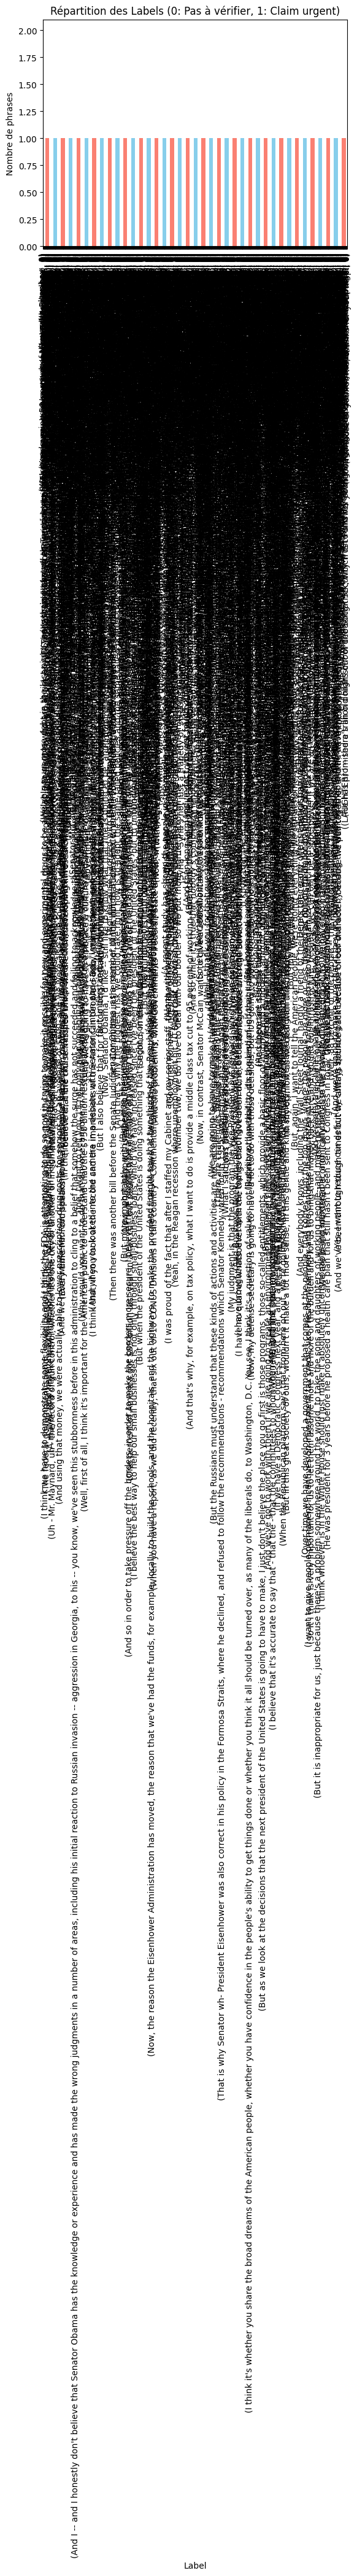

Proportion de Claims (Label 1) : 23.06%


In [11]:
import matplotlib.pyplot as plt

counts = dataset['labels'].value_counts()
print("Répartition originale du Verdict :")
print(counts)

# Visualisation

dataset.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Répartition des Labels (0: Pas à vérifier, 1: Claim urgent)")
plt.xlabel("Label")
plt.ylabel("Nombre de phrases")
plt.show()

#Calcul du ratio
ratio = dataset['labels'].value_counts(normalize=True)
print(f"Proportion de Claims (Label 1) : {ratio[1]:.2%}")

On a un dataset déséquilibré. La proportion de claims est trop basse, il faut donc lui donner plus de poids.

In [12]:
from sklearn.utils import resample

df_majority = dataset[dataset['labels'] ==0]
df_minority = dataset[dataset['labels'] ==1]

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

dataset = pd.concat([df_majority, df_minority_upsampled])

On exécute à nouveau le code permettant d'afficher le graphique des proportions de claims et non claims

Répartition originale du Verdict :
labels
0    794
1    794
Name: count, dtype: int64


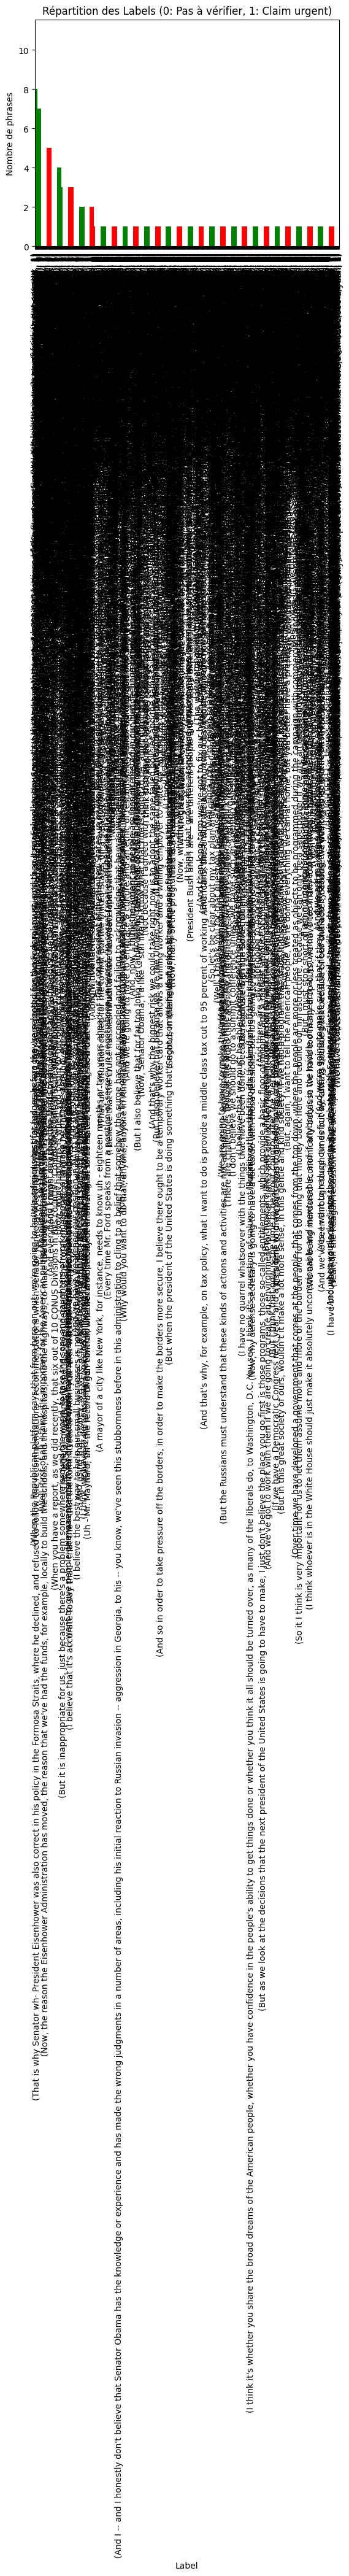

Proportion de Claims (Label 1) : 50.00%


In [13]:
counts = dataset['labels'].value_counts()
print("Répartition originale du Verdict :")
print(counts)

# Visualisation

dataset.value_counts().plot(kind='bar', color=['red', 'green'])
plt.title("Répartition des Labels (0: Pas à vérifier, 1: Claim urgent)")
plt.xlabel("Label")
plt.ylabel("Nombre de phrases")
plt.show()

#Calcul du ratio
ratio = dataset['labels'].value_counts(normalize=True)
print(f"Proportion de Claims (Label 1) : {ratio[1]:.2%}")

Les deux datasets sont donc maintenant équilibrés

In [14]:
# 🧹 LIBÉRER LA MÉMOIRE GPU AVANT L'ENTRAÎNEMENT
import torch
import gc
import os

# Variables d'environnement pour éviter fragmentation GPU
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Vider le cache GPU
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Forcer le garbage collection
gc.collect()

# Afficher l'espace GPU disponible
if torch.cuda.is_available():
    torch.cuda.synchronize()
    free_memory = torch.cuda.mem_get_info()[0] / 1e9
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    used_memory = total_memory - free_memory
    print(f"🧹 Mémoire GPU nettoyée!")
    print(f"💾 GPU VRAM - Utilisée: {used_memory:.2f}GB | Libre: {free_memory:.2f}GB | Total: {total_memory:.2f}GB")
    if free_memory < 2.0:
        print("❌ ATTENTION: Moins de 2GB libres! Redémarrez le kernel SVP.")
else:
    print("⚠️ Pas de GPU disponible")


🧹 Mémoire GPU nettoyée!
💾 GPU VRAM - Utilisée: 5.39GB | Libre: 2.78GB | Total: 8.18GB


In [15]:
from datasets import Dataset, DatasetDict

dataset = dataset[['Text', 'labels']].rename(columns={'labels': 'label'})
# On transforme le DataFrame en Dataset Hugging Face
hg_dataset = Dataset.from_pandas(dataset[['Text', 'label']])

# on divise notre dataset en train/test

split_dataset = hg_dataset.train_test_split(test_size=0.2)

In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    # L'option batched=True envoie une liste de textes ici
    return tokenizer(examples["Text"], padding="max_length", truncation=True)

tokenized_datasets = split_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

# 🔧 OPTIMISÉ POUR RTX 4060 (8GB VRAM) - Batch size minimal
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=2,   # Minimal pour éviter OOM
    per_device_eval_batch_size=2,    # Petit batch pour eval
    num_train_epochs=2,              # 2 epochs
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    seed=42,
    warmup_steps=0,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

# Lancer l'entraînement
print("🚀 Début de l'entraînement...")
print(f"📊 Configuration: batch_size=2 | epochs=2 | device={trainer.args.device}")
trainer.train()

Map:   0%|          | 0/1270 [00:00<?, ? examples/s]

Map:   0%|          | 0/318 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Début de l'entraînement...
📊 Configuration: batch_size=2 | epochs=2 | device=cuda:0


Epoch,Training Loss,Validation Loss
1,0.159047,0.185046
2,0.075669,0.194021


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1270, training_loss=0.1371954751354972, metrics={'train_runtime': 106.419, 'train_samples_per_second': 23.868, 'train_steps_per_second': 11.934, 'total_flos': 336467192586240.0, 'train_loss': 0.1371954751354972, 'epoch': 2.0})

In [17]:
trainer.save_model("./my_claim_model")
tokenizer.save_pretrained("./my_claim_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./my_claim_model/tokenizer_config.json', './my_claim_model/tokenizer.json')

In [18]:
from transformers import pipeline

claim_pipeline = pipeline(
    "text-classification",
    model="./my_claim_model",
    tokenizer="./my_claim_model",
    device=0,
    return_all_scores=True
)

def detect_claim(text, threshold=0.5):
    # On récupère le premier (et seul) élément de la liste retournée
    raw_results = claim_pipeline(text)

    # Hugging Face renvoie souvent [[{...}, {...}]]
    # On "aplatit" pour avoir juste la liste de dictionnaires
    results = raw_results[0] if isinstance(raw_results[0], list) else raw_results

    score_claim = 0
    for r in results:
        if r['label'] == 'LABEL_1':
            score_claim = r['score']
            break

    return score_claim > threshold, score_claim

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Prédiction sur l'ensemble de test
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# matrice de confusion

confusion_matrix = confusion_matrix(labels, preds)
print("Matrice de confusion :")
print(confusion_matrix)

# rapport de classification
print("\nRapport de classification :")

print(classification_report(labels, preds, target_names=["Non-Claim", "Claim"]))

Matrice de confusion :
[[158  11]
 [  1 148]]

Rapport de classification :
              precision    recall  f1-score   support

   Non-Claim       0.99      0.93      0.96       169
       Claim       0.93      0.99      0.96       149

    accuracy                           0.96       318
   macro avg       0.96      0.96      0.96       318
weighted avg       0.96      0.96      0.96       318



les métriques sont satisfaisantes pour la classe claim, elles sont toutes supérieures à 95%. On va maintenant faire un autre test pour savoir si le claim detector est vraiment efficace

In [20]:
print(detect_claim("The unemployment rate in France is 7.5%", threshold=0.5))
print(detect_claim("The Eiffel Tower is 330 meters tall", threshold=0.5))
print(detect_claim("there are 6 continents on planet earth", threshold=0.5))
print(detect_claim("Avatar is a great movie", threshold=0.5))
print(detect_claim("I think this movie is great", threshold=0.5))
print(detect_claim("Hello, how are you today?", threshold=0.5))

(True, 0.9981371164321899)
(True, 0.9840524196624756)
(True, 0.9904692769050598)
(False, 0)
(False, 0)
(False, 0)


Il semblerait donc que le claim detector fonctionne bien, il est parvenu à différencier une information factuelle d'une opinion.

# Evidence Retrieval

In [21]:
! pip install wikipedia-api

In [22]:
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 8.0 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 3.3 MB/s  0:00:05 eta 0:00:01m
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 8.0 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [23]:
import wikipediaapi
import spacy
import requests

class EvidenceRetriever:
  def __init__(self, google_api_key=None, google_cse_id=None, wolfram_app_id=None,
                 config_languages={'en': 'en_core_web_sm', 'fr': 'fr_core_news_sm'}):
      self.wiki_instances = {}
      self.nlp_models = {}
      self.google_api_key = google_api_key
      self.google_cse_id = google_cse_id
      self.wolfram_app_id = wolfram_app_id

      user_agent = "FakeNewsDetectionProject/1.0 "

      for language, spacy_models in config_languages.items():
        self.wiki_instances[language] = wikipediaapi.Wikipedia(
            user_agent=user_agent, language=language)

        try:
          self.nlp_models[language] = spacy.load(spacy_models)

        except OSError:
          print(f"⚠️ Modèle {spacy_models} manquant.")

  def extract_entities(self, text, language):
      nlp = self.nlp_models.get(language)
      if not nlp:
        return text
      doc = nlp(text)
      entities = [ent.text for ent in doc.ents if ent.label_ in ['PERSON', 'LOC', 'GPE', 'ORG', 'FAC']]
      return " ".join(entities) if entities else text

  def get_wolfram_evidence(self, claim):
    if not self.wolfram_app_id:
      return None
    url = "http://api.wolframalpha.com/v1/result"
    parameters = {
        "appid": self.wolfram_app_id, "i": claim
    }
    try:
      response = requests.get(url, params=parameters)
      if response.status_code == 200:
          return {"title": "WolframAlpha", "content": response.text, "url": "https://www.wolframalpha.com"}
    except: return None

  def get_google_politifact_evidence(self, claim):
    if not self.google_api_key:
      return None
    query = f"site:politifact.com OR site:lemonde.fr {claim}"
    url = "https://www.googleapis.com/customsearch/v1"
    params = {"key": self.google_api_key, "cx": self.google_cse_id, "q": query}

    try:
      response = requests.get(url, params=params).json()
      if 'items' in response:
        return {"title": response['items'][0]['title'], "content": response['items'][0]['snippet'], "url": response['items'][0]['link']}
    except:
      return None


  def get_evidence(self, claim_text, language='en'):

    # 1. Wolfram

    #
    evidence = self.get_wolfram_evidence(claim_text)

    if evidence and len(evidence['content']) > 150:
      return evidence

    # Fonction interne spécifiquement pour wikipédia

    def wiki_query(search_string):
      wiki = self.wiki_instances.get(language)
      if not wiki:
        return None
      search_url = f"https://{language}.wikipedia.org/w/api.php"
      params = {"action": "opensearch", "search": search_string, "limit": 1, "format": "json"}
      try:
            r = requests.get(search_url, params=params, headers={"User-Agent": "FactChecker/1.0"})
            data = r.json()
            if len(data) > 1 and data[1]:
                page = wiki.page(data[1][0])
                if page.exists():
                    return {"title": page.title, "content": page.summary[:1200], "url": page.fullurl}
      except: pass
      return None

    # stratégie de repli = fallback

    wiki_env = wiki_query(claim_text)
    if wiki_env:
      return wiki_env

    keywords = self.extract_entities(claim_text, language)
    wiki_ev = wiki_query(keywords)
    if wiki_ev: return wiki_ev

    return evidence if evidence else None



In [24]:
# Remplace par tes vraies clés obtenues sur les portails
WOLFRAM_APPID = "LEU7Y6728T"
GOOGLE_API_KEY = None
GOOGLE_CSE_ID = "151bf4aa4eae44373"

# Initialisation du nouveau Retriever
retriever = EvidenceRetriever(
    google_api_key=GOOGLE_API_KEY,
    google_cse_id=GOOGLE_CSE_ID,
    wolfram_app_id=WOLFRAM_APPID,
    config_languages={'en': 'en_core_web_sm', 'fr': 'fr_core_news_sm', 'es': 'es_core_news_sm'}
)

test_claims = {
    "The Eiffel Tower is 330 meters tall": "en",
    "Le taux de chômage en France est de 7%": "fr",
    "The Eiffel Tower was built in 1990": "en",
    "The unemployment rate in France is 7%": "en",
    "La tour Eiffel mesure 330 mètres de haut": "fr",
    "La capital de España es Madrid": "es"
}

print("--- Lancement du Test Multi-Sources ---\n")

for claim, language in test_claims.items():
    # On utilise la méthode qui gère les priorités
    evidence = retriever.get_evidence(claim, language)

    if evidence:
        source_name = evidence.get('title', 'Inconnue')
        print(f"✅ Trouvé via [{source_name}] ({language})")
        print(f"Phrase : {claim}")
        print(f"Preuve : {evidence['content'][:150]}...")
        print(f"Lien : {evidence.get('url', 'N/A')}\n")
    else:
        print(f"❌ Aucune preuve trouvée pour : {claim}\n")

--- Lancement du Test Multi-Sources ---

✅ Trouvé via [Eiffel Tower] (en)
Phrase : The Eiffel Tower is 330 meters tall
Preuve : The Eiffel Tower (  EYE-fəl; French: Tour Eiffel [tuʁ ɛfɛl] ) is a lattice tower on the Champ de Mars in Paris, France. It is named after the engineer...
Lien : https://en.wikipedia.org/wiki/Eiffel_Tower

✅ Trouvé via [France] (fr)
Phrase : Le taux de chômage en France est de 7%
Preuve : La France, en forme longue la République française, est un État souverain transcontinental dont le territoire métropolitain s'étend en Europe de l'Oue...
Lien : https://fr.wikipedia.org/wiki/France

✅ Trouvé via [Eiffel Tower] (en)
Phrase : The Eiffel Tower was built in 1990
Preuve : The Eiffel Tower (  EYE-fəl; French: Tour Eiffel [tuʁ ɛfɛl] ) is a lattice tower on the Champ de Mars in Paris, France. It is named after the engineer...
Lien : https://en.wikipedia.org/wiki/Eiffel_Tower

✅ Trouvé via [France] (en)
Phrase : The unemployment rate in France is 7%
Preuve : France, of

# Claim Verification

In [25]:
from transformers import pipeline

class ClaimVerifier:
    def __init__(self):
        # Utilisation du modèle DeBERTa spécialisé
        self.model_name = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
        self.classifier = pipeline("text-classification", model=self.model_name, device=0)

    def verify(self, claim, evidence_text):
        if not evidence_text or len(evidence_text) < 20:
            return "NOT ENOUGH INFO", 0.0

        # Format optimal pour DeBERTa : la preuve d'abord, puis le claim
        text_input = f"{evidence_text[:1500]} [SEP] {claim}"

        try:
            result = self.classifier(text_input)[0]
            label = result['label'].lower()
            score = result['score']

            # Les modèles MNLI/FEVER utilisent souvent ces labels :
            if "entailment" in label:
                return "SUPPORTED", score
            elif "contradiction" in label:
                return "REFUTED", score
            else:
                return "NEUTRAL / NOT ENOUGH INFO", score

        except Exception as e:
            return f"ERROR: {str(e)}", 0.0

In [26]:
claimverifier = ClaimVerifier()
print(claimverifier.verify("New York is in the United States", "New York is one of the bigest city of the United States"))
print(claimverifier.verify("Tom Cruise was born in the United States", "Tom Cruise is an actor who is vegan"))
print(claimverifier.verify("Paris is the capital of France", "Paris is a big city located in Japan") )

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


('SUPPORTED', 0.9941257238388062)
('NEUTRAL / NOT ENOUGH INFO', 0.9987504482269287)
('REFUTED', 0.9910765886306763)


Evaluation des métriques de performances pour EvidenceRetriever et ClaimVerifier

In [27]:
import pandas as pd
import os

# 1. Chargement et Nettoyage
# 📂 Adapter le chemin pour l'environnement local
fever_file = str(DATA_DIR / 'train.jsonl')
print(f"📂 Chargement depuis : {fever_file}")
print(f"✅ Fichier existe : {os.path.exists(fever_file)}")

df_fever = pd.read_json(fever_file, lines=True)
mapping = {
    'SUPPORTS': 'SUPPORTED',
    'REFUTES': 'REFUTED',
    'NOT ENOUGH INFO': 'NEUTRAL / NOT ENOUGH INFO'
}
df_fever['label'] = df_fever['label'].replace(mapping)

# 2. Équilibrage (on prend 100 exemplaires de chaque classe présente dans le mapping)
n_per_class = 30
balanced_dfs = []
for label_value in df_fever['label'].unique():
    subset = df_fever[df_fever['label'] == label_value].sample(n=min(n_per_class, len(df_fever[df_fever['label'] == label_value])), random_state=42)
    balanced_dfs.append(subset)

balanced_df = pd.concat(balanced_dfs, ignore_index=True)

# 3. Mélanger le dataset (pour ne pas avoir tous les SUPPORTED au début)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Sélection des colonnes et conversion
test_data = balanced_df[['claim', 'label']]
test_data_list = test_data.to_dict('records')

print(f"Dataset équilibré créé : {len(test_data_list)} instances.")
print(balanced_df['label'].value_counts())
print(len(test_data_list))

📂 Chargement depuis : /home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/data/knowledge_based/train.jsonl
✅ Fichier existe : True
Dataset équilibré créé : 90 instances.
label
REFUTED                      30
SUPPORTED                    30
NEUTRAL / NOT ENOUGH INFO    30
Name: count, dtype: int64
90


In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def check_recovery_by_class(retriever, test_set):
    stats = {}
    for item in test_set:
        label = item['label']
        if label not in stats:
            stats[label] = {'total': 0, 'retrieved': 0} # On garde 'retrieved'
        stats[label]['total'] += 1
        evidence = retriever.get_evidence(item['claim'])

        if evidence and evidence['content'] and len(evidence['content']) > 20:
            stats[label]['retrieved'] += 1 # Correction ici

    print("\n🔍 ANALYSE DE RÉCUPÉRATION PAR CLASSE :")
    for label, count in stats.items():
        # Utiliser 'retrieved' au lieu de 'found'
        rate = (count['retrieved'] / count['total']) * 100
        print(f"Label {label:25} : {rate:.2f}% ({count['retrieved']}/{count['total']})")



def chek_verification(verifier, retriever, test_set):
    y_true = []
    y_pred = []
    retrieval_success = 0 # Initialisation manquante

    print(f"🚀 Début de l'évaluation sur {len(test_set)} instances...")

    for item in test_set:
        claim = item['claim']
        true_label = item['label']

        evidence = retriever.get_evidence(claim, language='en')

        if evidence and evidence['content']:
            retrieval_success += 1
            evidence_text = evidence['content']
        else:
            evidence_text = ""

        pred_label, score = verifier.verify(claim, evidence_text)
        y_true.append(true_label)
        y_pred.append(pred_label)
    # Calcul des métriques

    print("\n" + "="*30)
    print("RÉSULTATS DE L'ÉVALUATION")
    print("="*30)

    # Rapport de classification (Precision, Recall, F1)
    print("\n📋 Rapport de Classification :")
    print(classification_report(y_true, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred, labels=["SUPPORTED", "REFUTED", "NEUTRAL / NOT ENOUGH INFO"])
    plot_confusion_matrix(cm)


def plot_confusion_matrix(cm):
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["SUPP", "REFUT", "NEUT"],yticklabels=["SUPP", "REFUT", "NEUT"])
  plt.ylabel('Vrai Label')
  plt.xlabel('Prédiction')
  plt.title('Matrice de Confusion - Flux Sémantique')
  plt.show()



Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔍 ANALYSE DE RÉCUPÉRATION PAR CLASSE :
Label REFUTED                   : 53.33% (16/30)
Label SUPPORTED                 : 60.00% (18/30)
Label NEUTRAL / NOT ENOUGH INFO : 70.00% (21/30)
🚀 Début de l'évaluation sur 90 instances...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



RÉSULTATS DE L'ÉVALUATION

📋 Rapport de Classification :
                           precision    recall  f1-score   support

NEUTRAL / NOT ENOUGH INFO       0.45      0.47      0.46        30
          NOT ENOUGH INFO       0.00      0.00      0.00         0
                  REFUTED       0.60      0.30      0.40        30
                SUPPORTED       0.50      0.17      0.25        30

                 accuracy                           0.31        90
                macro avg       0.39      0.23      0.28        90
             weighted avg       0.52      0.31      0.37        90



/home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true

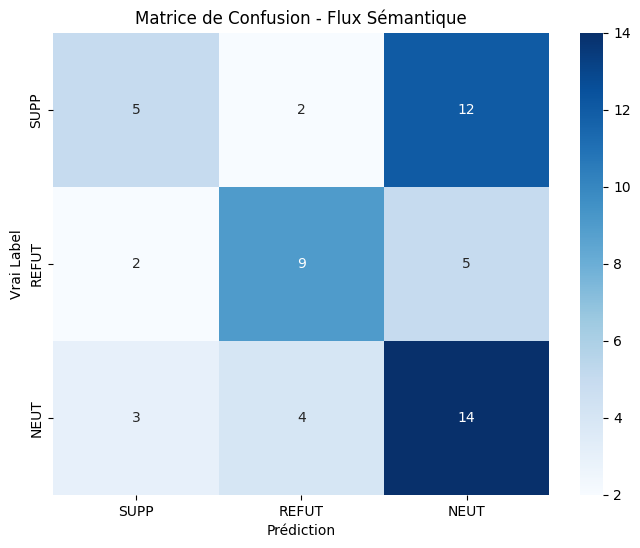

In [29]:
evidence_retriever = EvidenceRetriever(google_api_key=None, google_cse_id="151bf4aa4eae44373", wolfram_app_id="LEU7Y6728T")
claim_verifier = ClaimVerifier()
check_recovery_by_class(evidence_retriever, test_data_list)
chek_verification(claim_verifier,evidence_retriever, test_data_list)

Exécution du pipeline final

In [30]:
retriever = EvidenceRetriever(google_api_key=GOOGLE_API_KEY,
    google_cse_id="151bf4aa4eae44373",
    wolfram_app_id="LEU7Y6728T",
    config_languages={'en': 'en_core_web_sm', 'fr': 'fr_core_news_sm', 'es': 'es_core_news_sm'})

verifier = ClaimVerifier()

def process_full_text(text, language='en'):
    nlp = retriever.nlp_models.get(language)
    doc = nlp(text)
    final_report = []

    print(f"\n🚀 --- DÉBUT DU TRAITEMENT ({language.upper()}) ---")

    for sent in doc.sents:
        sentence = sent.text.strip()
        if not sentence: continue

        # 1. ÉTAPE DÉTECTION
        is_claim, detection_score = detect_claim(sentence, threshold=0.5)
        entites_trouvees = [ent.text for ent in sent.ents if ent.label_ in ['GPE', 'PERSON', 'DATE', 'ORG']]
        has_entities = len(entites_trouvees) > 0

        print(f"\n--- 📝 PHRASE : '{sentence}'")
        print(f"   [DÉTECTION] Score IA: {detection_score:.2f} | Entités: {entites_trouvees}")

        if is_claim or has_entities:
            # 2. ÉTAPE RÉCUPÉRATION
            print(f"   [RETRIEVER] Recherche de preuves en cours...")
            evidence = retriever.get_evidence(sentence, language)

            if evidence:
                source_name = evidence.get('title', 'Inconnue')
                # On print un extrait de ce que le retriever a VRAIMENT trouvé
                print(f"   ✅ SOURCE TROUVÉE : {source_name}")
                print(f"   📄 CONTENU EXTRAIT : {evidence['content'][:150]}...")
                print(f"   🔗 URL : {evidence.get('url')}")

                # 3. ÉTAPE VÉRIFICATION (Le Verifier a déjà ses propres prints)
                verdict, score_verif = verifier.verify(sentence, evidence['content'])

                final_report.append({
                    "phrase": sentence,
                    "verdict": verdict,
                    "score_detection": detection_score, # Le score de ton DistilBERT (0.94)
                    "score_verification": score_verif,  # Le score du NLI (confiance du verdict)
                    "source": evidence['url'],
                    "source_name": source_name
                })
            else:
                print(f"   ❌ RETRIEVER : Aucune preuve trouvée.")
                final_report.append({"phrase": sentence, "verdict": "NO EVIDENCE FOUND"})
        else:
            print(f"   ⏭️ IGNORÉ : Ne semble pas être un fait à vérifier.")

    print(f"\n--- ✅ TRAITEMENT TERMINÉ ---")
    return final_report

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test final

In [31]:
mon_article = """
Algeria is located in Africa. The Eiffel Tower is in Paris. The Eiffel Tower was built in 1990.

"""

resultats = process_full_text(mon_article, language='en')

# Affichage propre
for r in resultats:
    print(f"[{r['verdict']}] {r['phrase']} (Source: {r.get('source', 'N/A')})")


🚀 --- DÉBUT DU TRAITEMENT (EN) ---

--- 📝 PHRASE : 'Algeria is located in Africa.'
   [DÉTECTION] Score IA: 0.00 | Entités: ['Algeria']
   [RETRIEVER] Recherche de preuves en cours...
   ✅ SOURCE TROUVÉE : Algeria at the Africa Cup of Nations
   📄 CONTENU EXTRAIT : Algeria have appeared in the finals of the Africa Cup of Nations on twenty occasions. The side's first participation was in 1968 in Ethiopia. Algeria ...
   🔗 URL : https://en.wikipedia.org/wiki/Algeria_at_the_Africa_Cup_of_Nations

--- 📝 PHRASE : 'The Eiffel Tower is in Paris.'
   [DÉTECTION] Score IA: 0.72 | Entités: ['Paris']
   [RETRIEVER] Recherche de preuves en cours...
   ❌ RETRIEVER : Aucune preuve trouvée.

--- 📝 PHRASE : 'The Eiffel Tower was built in 1990.'
   [DÉTECTION] Score IA: 0.96 | Entités: ['1990']
   [RETRIEVER] Recherche de preuves en cours...
   ✅ SOURCE TROUVÉE : Eiffel Tower
   📄 CONTENU EXTRAIT : The Eiffel Tower (  EYE-fəl; French: Tour Eiffel [tuʁ ɛfɛl] ) is a lattice tower on the Champ de Mars in